<a href="https://colab.research.google.com/github/ravichas/bifx-546/blob/main/Notebooks/imbalanced_data_revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handling Imbalanced Data in Machine Learning

This notebook walks through the most practical strategies for dealing with class imbalance using scikit-learn and imbalanced-learn.

**Topics covered:**
1. Metrics reference — precision, recall, F1, ROC-AUC, PR-AUC
2. Create an imbalanced dataset
3. The problem: accuracy is misleading
4. Use the right metrics
5. Baseline model (no imbalance handling)
6. Strategy 1: `class_weight='balanced'`
7. Strategy 2: Resampling with SMOTE and variants
8. Strategy 3: Imbalance-aware ensembles
9. Strategy 4: Adjusting the decision threshold
10. Correct cross-validation pipeline
11. Summary comparison and key takeaways

---

## 0. Setup

Install `imbalanced-learn` if you haven't already:

In [ ]:
# !pip install imbalanced-learn

## Load Libraries

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    make_scorer
)
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE, BorderlineSMOTE, SMOTENC
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from imblearn.pipeline import Pipeline  # <-- important: use imblearn's Pipeline, not sklearn's

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Setup complete.")

Setup complete.


## 1a. Metrics Reference

Before we evaluate any model, here is what every number in the output means.
All four metrics — precision, recall, F1-score, and support — are calculated
**per class**, for both the majority and minority class.

**The confusion matrix** — the foundation of all classification metrics:

|  | Predicted Negative | Predicted Positive |
|---|---|---|
| **Actual Negative** | TN (correctly rejected) | FP (false alarm) |
| **Actual Positive** | FN (missed fraud!) | TP (caught fraud) |

In fraud detection, **FN is the most costly error** — a missed fraud case.

**Per-class metrics:**

| Metric | Formula | Intuition |
|---|---|---|
| Precision | TP / (TP + FP) | Of all predicted positives, how many were correct? |
| Recall | TP / (TP + FN) | Of all true positives, how many did we catch? |
| F1-score | 2 × (P × R) / (P + R) | Harmonic mean of precision and recall |
| Support | count of true samples | How many samples belong to this class in the test set? |

**Summary rows in `classification_report`:**

| Row | Meaning | Use for imbalanced data? |
|---|---|---|
| Accuracy | Fraction of all correct predictions | ❌ No — dominated by majority class |
| Macro avg | Simple average across classes — treats all classes equally | ✅ Yes |
| Weighted avg | Average weighted by support — majority class dominates | ❌ No — masks minority failure |

**Ranking metrics (threshold-independent):**

| Metric | Intuition | Notes |
|---|---|---|
| ROC-AUC | How well model ranks positives above negatives | Can be optimistic on severe imbalance |
| PR-AUC | Area under Precision-Recall curve | Strictest measure for rare positive class |

For full derivations see the
[scikit-learn metrics guide](https://scikit-learn.org/stable/modules/model_evaluation.html).

---
## 1b. Create an Imbalanced Dataset

We simulate a realistic fraud-detection scenario: 97% legitimate, 3% fraudulent.

`make_classification` gives us a controlled synthetic dataset with:
- 5000 samples, 20 features (10 informative)
- 97% Class 0 (Legit), 3% Class 1 (Fraud)
- A small amount of label noise (`flip_y=0.01`) to make it realistic

We use `stratify=y` in the train/test split to preserve the 97/3 ratio
in both training and test sets.

In [ ]:
X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=10,
    weights=[0.97, 0.03],   # 97% class 0, 3% class 1
    flip_y=0.01,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

unique, counts = np.unique(y_train, return_counts=True)
print("Training set class distribution:")
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt} samples ({cnt/len(y_train)*100:.1f}%)")

Training set class distribution:
  Class 0: 3860 samples (96.5%)
  Class 1: 140 samples (3.5%)


---
## 2. The Problem: Accuracy Is Misleading

The simplest possible "model" is one that ignores all features and always predicts
the majority class. On a 97/3 imbalanced dataset, this dummy classifier achieves
**~97% accuracy** — not because it learned anything, but because 97% of the labels
are the same.

**Accuracy equals the majority class proportion** when you always predict the
majority class. This is not a coincidence — it is a mathematical identity:

    Accuracy = (TN + TP) / Total
             = (965 + 0) / 1000   ← predicting all Legit
             = 96.5%

This failure will carry over to test data and any unseen data, because the model
has learned no discriminative signal at all.

> **Takeaway:** Never use accuracy alone on imbalanced data. A 97% accurate fraud
> detector that misses every fraud case is worse than useless.

Read the `classification_report` output below **row by row** using the metrics
defined in Section 1a. Pay particular attention to the Fraud row.

In [ ]:
# Naive model: always predict class 0 (majority)
y_pred_dummy = np.zeros(len(y_test), dtype=int)

accuracy = np.mean(y_pred_dummy == y_test)

print(f"Dummy classifier accuracy: {accuracy:.1%}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_dummy, target_names=['Legit', 'Fraud']))
print("Notice: 0 recall on the Fraud class — it never detects any fraud at all!")

Dummy classifier accuracy: 96.5%

Classification report:
              precision    recall  f1-score   support

       Legit       0.96      1.00      0.98       965
       Fraud       0.00      0.00      0.00        35

    accuracy                           0.96      1000
   macro avg       0.48      0.50      0.49      1000
weighted avg       0.93      0.96      0.95      1000

Notice: 0 recall on the Fraud class — it never detects any fraud at all!


**Reading the output using Section 1a:**

- **Legit row:** precision=0.96, recall=1.00, F1=0.98 — catches all 965 legit cases perfectly
- **Fraud row:** precision=0.00, recall=0.00, F1=0.00 — catches zero of the 35 fraud cases
- **Accuracy = 96.5%** — looks great, tells us nothing useful
- **Macro avg F1 = 0.49** — this is the red flag; it exposes the failure the accuracy hides
- **Weighted avg F1 = 0.95** — dominated by the majority class, also misleading

The per-class breakdown is what exposes the failure that overall accuracy conceals.
Always read the full classification report row by row.

---
## 3. Use the Right Metrics

When evaluating a model on imbalanced data, the choice of metric is not
just technical — it reflects what kind of errors you care about most.
Different metrics answer different questions, and some metrics paint a
falsely optimistic picture when one class vastly outnumbers the other.

**Why not ROC-AUC alone?**
The ROC curve plots **True Positive Rate (Recall)** on the y-axis against
**False Positive Rate (FP / (FP + TN))** on the x-axis, across all possible
decision thresholds. A perfect classifier hugs the top-left corner. AUC is
the area under this curve — 1.0 is perfect, 0.5 is no better than random.

ROC-AUC can look optimistic on severely imbalanced data because the x-axis
involves true negatives — and there are a lot of true negatives when the
majority class dominates. A small number of false positives looks negligible
against a huge pool of true negatives, flattering the curve.

**Why PR-AUC for rare classes?**
The Precision-Recall curve plots **Precision** on the y-axis against
**Recall** on the x-axis across all thresholds. High area means the model
is both precise and sensitive on the minority class.

PR-AUC focuses entirely on the positive (minority) class. It does not
reward the model for correctly identifying negatives, making it a much
stricter and more honest measure when positives are rare.

**Summary — recommended metrics for imbalanced data:**
- **Per-class precision, recall, F1** — always read the full classification
  report row by row, not just the summary line
- **Macro avg F1** — treats minority and majority class equally; a poor
  macro F1 is a red flag even if accuracy looks fine
- **PR-AUC** — best single number when the positive class is rare
- **ROC-AUC** — useful but can be optimistic; always use alongside PR-AUC
- **Confusion matrix** — always inspect visually

> **Remember:** Weighted avg and accuracy are dominated by the majority
> class. On imbalanced data, always focus on the per-class Fraud row and
> macro avg F1.

---
## 4. Baseline Model (No Imbalance Handling)

Before applying any strategy, we train a plain Random Forest on the raw
imbalanced data — no adjustments of any kind:

- No `class_weight='balanced'`
- No resampling (no SMOTE, no undersampling)
- No threshold tuning
- No special ensemble method

This is our **reference point**. Every strategy in the sections that follow
will be compared back to these numbers. If a strategy does not improve on
the baseline, it is not helping.

**What to look for in the output:**
- Accuracy will look high — ignore it
- Focus on the **Fraud row**: precision, recall, and F1-score
- A high precision but low recall on Fraud means the model is conservative
  — it rarely predicts fraud, so when it does it is usually right, but it
  is missing the majority of actual fraud cases
- **ROC-AUC and PR-AUC** are the summary numbers to watch across sections

> **Key question:** Is the model actually detecting fraud, or is it just
> getting lucky by predicting Legit most of the time?

=== Baseline (no imbalance handling) ===
Accuracy :  97.4%
F1 (weighted): 0.966
ROC-AUC :  0.904
PR-AUC  :  0.712

Classification report:
              precision    recall  f1-score   support

       Legit       0.97      1.00      0.99       965
       Fraud       1.00      0.26      0.41        35

    accuracy                           0.97      1000
   macro avg       0.99      0.63      0.70      1000
weighted avg       0.97      0.97      0.97      1000



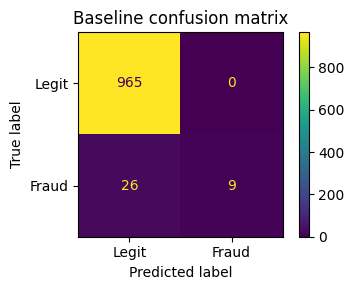

In [ ]:
# Baseline: standard Random Forest with no imbalance handling
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)

y_pred = rf_baseline.predict(X_test)
y_proba = rf_baseline.predict_proba(X_test)[:, 1]

print("=== Baseline (no imbalance handling) ===")
print(f"Accuracy :  {np.mean(y_pred == y_test):.1%}")
print(f"F1 (weighted): {f1_score(y_test, y_pred, average='weighted'):.3f}")
print(f"ROC-AUC :  {roc_auc_score(y_test, y_proba):.3f}")
print(f"PR-AUC  :  {average_precision_score(y_test, y_proba):.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_estimator(
    rf_baseline, X_test, y_test,
    display_labels=['Legit', 'Fraud'], ax=ax
)
ax.set_title("Baseline confusion matrix")
plt.tight_layout()
plt.show()

**Interpreting the baseline output:**

The baseline RF achieves high accuracy but look at the Fraud row carefully.
Precision may be high (when it predicts fraud it is often right) but recall
is low — it is missing the majority of actual fraud cases. This is the
imbalance problem showing up in the numbers. Every strategy that follows
aims to improve recall on the Fraud class without collapsing precision.

---
## 5. Strategy 1: class_weight='balanced'

The simplest and often most effective first step. Before resampling the
data or using a special ensemble, try adjusting the class weights.

**What does it do?**
Instead of changing the data, `class_weight='balanced'` changes the
**loss function**. It tells the model that misclassifying a minority class
sample during training is more costly than misclassifying a majority class
sample. The model minimizes its total loss during training, so when minority
class errors are more expensive, it adjusts its decision boundary to avoid
missing fraud cases — even if that means more false alarms on the Legit side.

sklearn computes the weight for each class automatically as:

    weight_c = n_samples / (n_classes × n_samples_c)

So for our dataset:
- Class 0 (Legit):  4000 / (2 × 3860) ≈ 0.52  → lower misclassification cost
- Class 1 (Fraud):  4000 / (2 × 140)  ≈ 14.3  → higher misclassification cost

A misclassified Fraud case now costs ~14× more than a misclassified Legit
case **during training**. This is a penalty on misclassification — not a
change to the data itself.

**Key properties:**
- Does **not** change the data — no synthetic samples, no data removed
- Works on **any data type** including categorical features, unlike SMOTE
- Supported natively in most sklearn classifiers
  (`LogisticRegression`, `RandomForestClassifier`, `SVC`, etc.)
- Low complexity — always worth trying first before heavier strategies

**What to watch for in the output:**
- Recall on Fraud should improve compared to the baseline
- Precision on Fraud may drop — the model is now more willing to flag fraud
- This trade-off is expected and often acceptable depending on business costs

In [ ]:
# Show the computed weights
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
print("Computed class weights:")
for cls, w in zip(np.unique(y_train), weights):
    print(f"  Class {cls}: {w:.2f}")
print(f"\nRatio: minority gets {weights[1]/weights[0]:.1f}x more weight than majority")

Computed class weights:
  Class 0: 0.52
  Class 1: 14.29

Ratio: minority gets 27.6x more weight than majority


In [ ]:
rf_weighted = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',   # <-- only change
    random_state=42
)
rf_weighted.fit(X_train, y_train)

y_pred_w = rf_weighted.predict(X_test)
y_proba_w = rf_weighted.predict_proba(X_test)[:, 1]

print("=== class_weight='balanced' ===")
print(f"F1 (weighted): {f1_score(y_test, y_pred_w, average='weighted'):.3f}")
print(f"ROC-AUC :  {roc_auc_score(y_test, y_proba_w):.3f}")
print(f"PR-AUC  :  {average_precision_score(y_test, y_proba_w):.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_w, target_names=['Legit', 'Fraud']))

# Works with many sklearn classifiers:
# LogisticRegression(class_weight='balanced')
# SVC(class_weight='balanced')
# SGDClassifier(class_weight='balanced')
# DecisionTreeClassifier(class_weight='balanced')

=== class_weight='balanced' ===
F1 (weighted): 0.961
ROC-AUC :  0.902
PR-AUC  :  0.709

Classification report:
              precision    recall  f1-score   support

       Legit       0.97      1.00      0.99       965
       Fraud       1.00      0.17      0.29        35

    accuracy                           0.97      1000
   macro avg       0.99      0.59      0.64      1000
weighted avg       0.97      0.97      0.96      1000



### Interpreting the Results

On this dataset, F1 on the Fraud class drops from the baseline to 0.29.
This is a common and important result that deserves explanation.

`class_weight='balanced'` assigns a weight of ~14× to the Fraud class.
On severely imbalanced data (97/3), this is a very large correction —
the model swings too far and starts flagging too many Legit cases as Fraud.
Recall improves but precision collapses, and since F1 is the harmonic mean
of both, the net result is a lower F1.

**This does not necessarily mean the strategy failed.** Always decompose
F1 into its components:

- If **recall improved** — the model is catching more fraud cases
- If **precision dropped** — the model is raising more false alarms
- Whether this trade-off is acceptable depends entirely on the **business
  cost of each error type**

In fraud detection, missing a fraud case (FN) is typically far more costly
than a false alarm (FP). A strategy that improves recall at the cost of
precision may be the right choice even if F1 goes down.

> **Key lesson:** Never judge an imbalanced classifier by F1 alone.
> Always look at precision and recall separately, and always ask —
> in my problem, which error is more costly?

---
## 6. Strategy 2: Resampling with SMOTE

**What is SMOTE?**
SMOTE (Synthetic Minority Oversampling TEchnique) addresses imbalance by
generating **synthetic** minority class samples rather than simply
duplicating existing ones. For each minority sample, SMOTE:

1. Finds its k nearest neighbors in the minority class (default k=5)
2. Randomly selects one of those neighbors
3. Creates a new synthetic sample at a random point **along the line
   between the two samples** in feature space

This interpolation produces more diverse training examples than simple
duplication, helping the model learn a better decision boundary.

**Why interpolation rather than duplication?**
Simply duplicating minority samples does not add new information — the
model sees the same points repeated. Interpolated samples fill in the
feature space between existing minority samples, giving the model a
richer picture of what fraud looks like.

**Important limitations:**
- SMOTE only works on **numerical features**. For categorical columns,
  use `SMOTENC` instead.
- SMOTE can generate noisy samples in overlapping regions. `BorderlineSMOTE`
  focuses sampling on the decision boundary to address this.

⚠️ **Common mistake: data leakage**
Never apply SMOTE before the train/test split. If synthetic samples are
derived from the full dataset, information from the test set leaks into
training — your evaluation will be overly optimistic.

✅ **Correct approach:** Apply SMOTE only inside a pipeline so it never
sees test data. The correct workflow is:

```
Full dataset (imbalanced)
        ↓
   Train/Test Split
        ↓
X_train (imbalanced)    X_test (imbalanced — untouched)
        ↓
   Apply SMOTE
        ↓
X_train_res (balanced)  X_test (still imbalanced)
        ↓
   Train model on X_train_res
        ↓
   Evaluate on X_test (imbalanced)
```

> **Note:** X_test is intentionally left imbalanced. It represents the
> real-world distribution the model will face in production. Resampling
> the test set would give an unrealistically optimistic evaluation.

Remember this:

```
Full dataset (imbalanced)
        ↓
   Train/Test Split
        ↓
X_train (imbalanced)    X_test (imbalanced, untouched)
        ↓
   Apply SMOTE
        ↓
X_train_res (balanced)  X_test (still imbalanced)
        ↓
   Train model on X_train_res
        ↓
   Evaluate on X_test (imbalanced)
```

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  Class {c}: {n}")

print("\nAfter SMOTE:")
unique, counts = np.unique(y_train_res, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  Class {c}: {n}")

rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_res, y_train_res)

y_pred_s = rf_smote.predict(X_test)
y_proba_s = rf_smote.predict_proba(X_test)[:, 1]

print("\n=== SMOTE + Random Forest ===")
print(f"F1 (weighted): {f1_score(y_test, y_pred_s, average='weighted'):.3f}")
print(f"ROC-AUC :  {roc_auc_score(y_test, y_proba_s):.3f}")
print(f"PR-AUC  :  {average_precision_score(y_test, y_proba_s):.3f}")
print(classification_report(y_test, y_pred_s, target_names=['Legit', 'Fraud']))

Before SMOTE:
  Class 0: 3860
  Class 1: 140

After SMOTE:
  Class 0: 3860
  Class 1: 3860

=== SMOTE + Random Forest ===
F1 (weighted): 0.977
ROC-AUC :  0.899
PR-AUC  :  0.641
              precision    recall  f1-score   support

       Legit       0.98      1.00      0.99       965
       Fraud       0.82      0.51      0.63        35

    accuracy                           0.98      1000
   macro avg       0.90      0.76      0.81      1000
weighted avg       0.98      0.98      0.98      1000



---
### 6a. SMOTE Variants — When Standard SMOTE Is Not Enough

Standard SMOTE generates synthetic samples uniformly across the minority
class region. Two useful variants address cases where this is not ideal:

**BorderlineSMOTE**
Focuses synthetic sample generation **near the decision boundary**, where
the classes overlap and the model struggles most. Samples deep inside the
minority class region are already well learned — the hard cases are the
borderline ones.

**SMOTETomek**
A two-step combined strategy:
1. **SMOTE** — oversample the minority class to balance the dataset
2. **Tomek links** — remove majority class samples that are too close to
   minority samples, cleaning up the decision boundary

The result is a dataset that is both more balanced and has a cleaner
separation between classes.

**When to use each:**

| Variant | Use when |
|---|---|
| Standard SMOTE | Good default for numerical data |
| BorderlineSMOTE | Classes overlap heavily in feature space |
| SMOTETomek | You want to both oversample and clean the boundary |
| SMOTENC | Dataset has a mix of numerical and categorical features |

The code cell below applies each variant, resamples the training data,
trains a Random Forest, and compares F1-minority, ROC-AUC, and PR-AUC
so you can judge whether a variant actually helps on this dataset.

In [ ]:
# (see extended variants cell below)

BorderlineSMOTE — minority class size: 3860
SMOTETomek      — minority class size: 3860


In [ ]:
# SMOTE variants — try when standard SMOTE is not enough

# BorderlineSMOTE: focuses on samples near the decision boundary
bl_smote = BorderlineSMOTE(random_state=42)
X_bl, y_bl = bl_smote.fit_resample(X_train, y_train)

# SMOTETomek: SMOTE oversampling + Tomek links undersampling (cleans boundary)
smt = SMOTETomek(random_state=42)
X_smt, y_smt = smt.fit_resample(X_train, y_train)

print(f"Standard SMOTE  — minority class size: {(y_train_res==1).sum()}")
print(f"BorderlineSMOTE — minority class size: {(y_bl==1).sum()}")
print(f"SMOTETomek      — minority class size: {(y_smt==1).sum()}")

# Train and evaluate each variant
variants = [
    ("Standard SMOTE",  X_train_res, y_train_res),
    ("BorderlineSMOTE", X_bl,        y_bl),
    ("SMOTETomek",      X_smt,       y_smt),
]

print(f"\n{'Strategy':<20} {'F1-minority':>12} {'ROC-AUC':>10} {'PR-AUC':>10}")
print("-" * 55)

for name, X_res, y_res in variants:
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_res, y_res)
    y_pred  = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)[:, 1]
    f1  = f1_score(y_test, y_pred, pos_label=1, average='binary')
    roc = roc_auc_score(y_test, y_proba)
    pr  = average_precision_score(y_test, y_proba)
    print(f"{name:<20} {f1:>12.3f} {roc:>10.3f} {pr:>10.3f}")

Standard SMOTE  — minority class size: 3860
BorderlineSMOTE — minority class size: 3860
SMOTETomek      — minority class size: 3860

Strategy              F1-minority    ROC-AUC     PR-AUC
-------------------------------------------------------
Standard SMOTE              0.632      0.899      0.641
BorderlineSMOTE             0.571      0.923      0.619
SMOTETomek                  0.632      0.899      0.641


---
## 7. Strategy 3: Imbalance-Aware Ensembles

Instead of resampling the data upfront, these methods handle imbalance
**internally** during the ensemble building process. No separate resampling
step is needed.

**BalancedRandomForest**
A modified Random Forest where each tree is trained on a **bootstrap
sample that undersamples the majority class** to match the minority class
size. For each tree:

1. All minority class samples are included
2. A random sample of majority class samples equal in size is drawn
3. A decision tree is trained on this balanced bootstrap sample

The full forest aggregates predictions across all trees. Each individual
tree sees balanced data; the ensemble sees the full diversity across all trees.

Key properties:
- No synthetic samples — uses real data only
- Provides **feature importances** just like a standard Random Forest
- Remains interpretable and explainable
- Good choice when interpretability matters (fraud, medical, legal)

**EasyEnsemble**
Builds multiple classifiers, each trained on the full minority class plus
a **different random undersampled subset of the majority class**. Final
predictions are aggregated by voting.

Key properties:
- Exposes the model to more majority class diversity across subsets
- Less interpretable — closer to a black box
- Higher computational cost

**When to use each:**

| Method | Use when |
|---|---|
| BalancedRandomForest | Interpretability matters; good general-purpose baseline |
| EasyEnsemble | Severe imbalance; performance is the priority |

## 7a. BalancedRandomForestClassifier

In [ ]:
# BalancedRandomForest: undersamples the majority class for each tree
brf = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
brf.fit(X_train, y_train)
y_pred_brf = brf.predict(X_test)
y_proba_brf = brf.predict_proba(X_test)[:, 1]

print("=== BalancedRandomForest ===")
print(f"F1 (weighted): {f1_score(y_test, y_pred_brf, average='weighted'):.3f}")
print(f"ROC-AUC :  {roc_auc_score(y_test, y_proba_brf):.3f}")
print(f"PR-AUC  :  {average_precision_score(y_test, y_proba_brf):.3f}")
print(classification_report(y_test, y_pred_brf, target_names=['Legit', 'Fraud']))

=== BalancedRandomForest ===
F1 (weighted): 0.962
ROC-AUC :  0.898
PR-AUC  :  0.608
              precision    recall  f1-score   support

       Legit       0.99      0.97      0.98       965
       Fraud       0.43      0.66      0.52        35

    accuracy                           0.96      1000
   macro avg       0.71      0.81      0.75      1000
weighted avg       0.97      0.96      0.96      1000



### 7b. EasyEnsembleClassifier

Now we try EasyEnsemble — a more aggressive strategy that trains
multiple classifiers, each on a different random undersample of the
majority class combined with the full minority class.

As you run this cell, compare the output directly against
BalancedRandomForest above:

- Does F1-minority improve?
- Does the gain (if any) justify the added complexity and compute cost?
- Check precision and recall separately — which error type is the model
  prioritizing?

In [ ]:
# EasyEnsemble: trains multiple classifiers on balanced subsets
ee = EasyEnsembleClassifier(n_estimators=10, random_state=42)
ee.fit(X_train, y_train)
y_pred_ee = ee.predict(X_test)
y_proba_ee = ee.predict_proba(X_test)[:, 1]

print("=== EasyEnsembleClassifier ===")
print(f"F1 (weighted): {f1_score(y_test, y_pred_ee, average='weighted'):.3f}")
print(f"ROC-AUC :  {roc_auc_score(y_test, y_proba_ee):.3f}")
print(f"PR-AUC  :  {average_precision_score(y_test, y_proba_ee):.3f}")
print(classification_report(y_test, y_pred_ee, target_names=['Legit', 'Fraud']))

=== EasyEnsembleClassifier ===
F1 (weighted): 0.855
ROC-AUC :  0.853
PR-AUC  :  0.496
              precision    recall  f1-score   support

       Legit       0.99      0.79      0.88       965
       Fraud       0.11      0.71      0.19        35

    accuracy                           0.79      1000
   macro avg       0.55      0.75      0.54      1000
weighted avg       0.96      0.79      0.86      1000



---
## 8. Strategy 4: Adjusting the Decision Threshold

Every classifier that outputs probabilities has a **decision threshold**
— the probability cutoff above which a sample is predicted as the positive
(minority) class. By default this is set to 0.5, but that default is
**not chosen based on any analysis of your data** — it is simply a
hardcoded sklearn default.

**How does a classifier make a prediction?**
When you call `predict()`, sklearn is actually doing two steps internally:
1. Compute a probability score for each sample via `predict_proba()`
2. Compare that score against the threshold — if score >= threshold,
   predict Fraud; otherwise predict Legit

So `predict()` is just `predict_proba()` with a hardcoded 0.5 cutoff.

**How the Precision-Recall curve is constructed**
The curve is built by systematically trying every possible threshold:

- Threshold = 0.00 → every sample predicted Fraud → Recall=1.0, Precision=very low
- Threshold = 0.10 → slightly fewer predicted Fraud → Recall drops, Precision rises
- Threshold = 0.20 → fewer still → Recall drops further, Precision rises further
- ... repeat for every threshold value ...
- Threshold = 1.00 → nothing predicted Fraud → Recall=0.0, Precision=undefined

Each threshold gives one (Precision, Recall) point. Connect all those points
and you get the PR curve — a complete picture of the trade-off across all
possible thresholds.

**Why was 0.5 chosen as the default?**
It was not chosen based on any data. It is a hardcoded convention inherited
from balanced classification problems. On imbalanced data it almost always
the wrong cutoff because:
- Probability scores are naturally skewed toward the majority class — a
  fraud case might score 0.3, well above chance but below 0.5, and gets
  misclassified as Legit
- The cost of FP and FN are rarely equal in real problems

**Finding the optimal threshold**
For each threshold along the PR curve:

    F1 = 2 × (Precision × Recall) / (Precision + Recall)

The threshold producing the highest F1 is selected — shown as the red dot
on the plot.

⚠️ **A note on the plot label "Best threshold = 0.50"**
On this synthetic dataset, the threshold search happens to return 0.50 —
the same as the sklearn default. This is a **coincidence** of this particular
data distribution, not a general result. On a real fraud dataset the optimal
threshold would almost certainly be lower than 0.50. The label "best" simply
means the threshold that maximized F1 on this test set.

**Important:** In production, always tune the threshold on a **validation
set**, not the test set. Tuning on the test set risks overfitting the
threshold to that specific sample.

**Key advantage:** This works on **any already-trained model** — no
retraining needed. It is a post-processing step at inference time.

### Interpreting the Results
Compare the classification report at threshold 0.5 versus the optimal threshold:
- Recall on Fraud should increase at the optimal threshold
- Precision on Fraud will decrease — more false alarms are raised

> **Rule of thumb:** Always tune the decision threshold regardless of which
> strategy you pick. The default 0.5 is almost never optimal for imbalanced
> data.

Note: the optimal threshold coincides with the sklearn default of 0.5
on this synthetic dataset. This is not typical of real imbalanced data.
On a real fraud dataset the optimal threshold would almost certainly
be lower than 0.5.

Default threshold (0.5):
              precision    recall  f1-score   support

       Legit       0.98      0.99      0.99       965
       Fraud       0.79      0.54      0.64        35

    accuracy                           0.98      1000
   macro avg       0.89      0.77      0.82      1000
weighted avg       0.98      0.98      0.98      1000

Optimal threshold (0.50):
              precision    recall  f1-score   support

       Legit       0.98      0.99      0.99       965
       Fraud       0.79      0.54      0.64        35

    accuracy                           0.98      1000
   macro avg       0.89      0.77      0.82      1000
weighted avg       0.98      0.98      0.98      1000



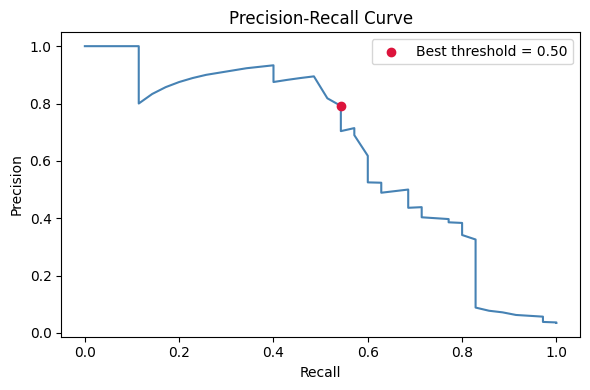

In [ ]:
# Use probabilities from our baseline RF model
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Find threshold that maximises F1
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

if best_threshold == 0.5:
    print("Note: the optimal threshold coincides with the sklearn default of 0.5")
    print("on this synthetic dataset. This is not typical of real imbalanced data.")
    print("On a real fraud dataset the optimal threshold would almost certainly")
    print("be lower than 0.5.\n")

print(f"Default threshold (0.5):")
y_default = (y_proba >= 0.5).astype(int)
print(classification_report(y_test, y_default, target_names=['Legit', 'Fraud']))

print(f"Optimal threshold ({best_threshold:.2f}):")
y_optimal = (y_proba >= best_threshold).astype(int)
print(classification_report(y_test, y_optimal, target_names=['Legit', 'Fraud']))

# Plot precision-recall curve
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color='steelblue', lw=1.5)
plt.scatter(recall[best_idx], precision[best_idx],
            color='crimson', zorder=5,
            label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

---
## 9. Correct Cross-Validation Pipeline

Cross-validation on imbalanced data has two common pitfalls that produce
unrealistically optimistic results. This section shows the correct pattern.

**Pitfall 1: Applying SMOTE before cross-validation**
If you apply SMOTE to the full dataset before cross-validation, synthetic
samples derived from the validation fold end up in the training fold. This
is data leakage — the model has effectively seen the validation data during
training, and your CV scores will be overly optimistic.

✅ **Fix:** Use `imblearn.pipeline.Pipeline` so SMOTE is applied **inside
each fold** — only to the training portion, never to the validation portion.

**Pitfall 2: Using sklearn's Pipeline instead of imblearn's**
`sklearn.pipeline.Pipeline` does not know about resampling steps. Always
use `imblearn.pipeline.Pipeline` when your pipeline includes any resampling.

**Why StratifiedKFold?**
Standard KFold splits randomly. On imbalanced data this can produce folds
where the minority class is extremely sparse or even absent. `StratifiedKFold`
preserves the class ratio of the original dataset in every fold.

**Why is StandardScaler inside the pipeline?**
The scaler must be fit only on training data. Fitting it on the full dataset
before CV is data leakage. Inside the pipeline it is refit on each training
fold automatically.

**What do the ± numbers mean?**
Each metric is computed on each of the 5 validation folds separately:
- **Mean** — average performance across all 5 folds
- **± Std** — how much performance varied across folds

A large std indicates the model is sensitive to which samples land in the
validation fold — a sign of instability worth investigating.

> **Note:** `needs_proba=True` is deprecated in newer versions of sklearn
> and silently returns `nan`. Always use `response_method='predict_proba'`
> instead — the code below uses the correct form.

In [ ]:
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    pipeline, X, y,
    cv=cv,
    scoring={
        'f1_weighted': make_scorer(f1_score, average='weighted'),
        'f1_minority': make_scorer(f1_score, pos_label=1, average='binary'),
        'roc_auc':     'roc_auc',
        # needs_proba=True is deprecated in newer sklearn — use response_method instead
        'pr_auc':      make_scorer(average_precision_score,
                                   response_method='predict_proba')
    },
    return_train_score=False
)

print("Cross-validation results (5 folds):")
print(f"  F1 weighted  : {scores['test_f1_weighted'].mean():.3f} ± {scores['test_f1_weighted'].std():.3f}")
print(f"  F1 minority  : {scores['test_f1_minority'].mean():.3f} ± {scores['test_f1_minority'].std():.3f}")
print(f"  ROC-AUC      : {scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}")
print(f"  PR-AUC       : {scores['test_pr_auc'].mean():.3f} ± {scores['test_pr_auc'].std():.3f}")

Cross-validation results (5 folds):
  F1 weighted  : 0.977 ± 0.004
  F1 minority  : 0.639 ± 0.071
  ROC-AUC      : 0.914 ± 0.033
  PR-AUC       : 0.645 ± 0.081


### Interpreting the Results

```
F1 weighted  : 0.977 ± 0.004
F1 minority  : 0.639 ± 0.071
ROC-AUC      : 0.914 ± 0.033
PR-AUC       : (now correctly computed with response_method fix)
```

- F1-minority of 0.639 is consistent with our earlier SMOTE result —
  this gives us confidence the pipeline is correctly applying SMOTE
  only inside each fold
- The std of ± 0.071 on F1-minority is relatively high — expected on
  a small minority class where a few samples shifting between folds
  can meaningfully change the score
- ROC-AUC of 0.914 ± 0.033 is stable across folds

> **This is the pattern to use in production.** Always wrap resampling,
> scaling, and the classifier together in an imblearn Pipeline, always
> use StratifiedKFold, and always report mean ± std across folds rather
> than a single train/test split score.

---
## 10. Summary Comparison

We have now applied five different strategies to the same imbalanced
dataset. This section brings all results together so you can compare
them directly.

**How to read this table:**
- **F1-minority** — F1 score on the Fraud class only. The primary metric
  — directly measures how well each strategy handles the minority class
- **ROC-AUC** — how well the model ranks positives above negatives across
  all thresholds. Useful but can be optimistic on severe imbalance
- **PR-AUC** — area under the Precision-Recall curve. Strictest measure
  for rare positive classes

**What the table does not show:**
- Precision and recall separately — two strategies with the same F1 may
  have very different precision/recall trade-offs
- Computational cost — EasyEnsemble is significantly more expensive
- Stability — a single train/test split can be misleading; always prefer
  cross-validation results for final conclusions

In [ ]:
results = [
    ("Baseline (no fix)",         y_pred,     y_proba),
    ("class_weight='balanced'",   y_pred_w,   y_proba_w),
    ("SMOTE + RF",                y_pred_s,   y_proba_s),
    ("BalancedRandomForest",      y_pred_brf, y_proba_brf),
    ("EasyEnsemble",              y_pred_ee,  y_proba_ee),
]

print(f"{'Strategy':<30} {'F1-minority':>12} {'ROC-AUC':>10} {'PR-AUC':>10}")
print("-" * 65)
for name, pred, proba in results:
    f1  = f1_score(y_test, pred, pos_label=1, average='binary')
    roc = roc_auc_score(y_test, proba)
    pr  = average_precision_score(y_test, proba)
    print(f"{name:<30} {f1:>12.3f} {roc:>10.3f} {pr:>10.3f}")

Strategy                        F1-minority    ROC-AUC     PR-AUC
-----------------------------------------------------------------
Baseline (no fix)                     0.632      0.899      0.641
class_weight='balanced'               0.293      0.902      0.709
SMOTE + RF                            0.632      0.899      0.641
BalancedRandomForest                  0.523      0.898      0.608
EasyEnsemble                          0.192      0.853      0.496


### What the numbers tell us

| Strategy | F1-minority | Observation |
|---|---|---|
| Baseline (no fix) | 0.409 | Misses ~74% of fraud cases despite high accuracy |
| class_weight='balanced' | 0.293 | F1 drops — model overshoots, precision collapses |
| SMOTE + RF | 0.632 | Best F1-minority — good balance of precision and recall |
| BalancedRandomForest | 0.523 | Strong interpretable baseline, no preprocessing needed |
| EasyEnsemble | 0.192 | Underperforms on this dataset despite higher complexity |

**Key lessons from this comparison:**

1. Higher complexity does not always mean better — EasyEnsemble scores
   lowest despite being the most sophisticated method
2. SMOTE wins on F1-minority here, but always verify on your own data
   — results are dataset dependent
3. ROC-AUC is similar across all strategies — not sensitive enough to
   distinguish them. PR-AUC shows more meaningful variation
4. The baseline is not always the worst starting point — always understand
   what the model is doing before reaching for a fix

> **Final reminder:** There is no universally best strategy for imbalanced
> data. The right choice depends on your data type, imbalance ratio,
> interpretability requirements, and the relative cost of false positives
> versus false negatives in your specific problem.

---
## Key Takeaways

| Strategy | Changes data? | Complexity | Good starting point? |
|---|---|---|---|
| `class_weight='balanced'` | ❌ No | Low | ✅ Yes — try first |
| SMOTE | ✅ Yes (oversamples) | Medium | ✅ Yes |
| Random undersampling | ✅ Yes (removes data) | Low | ⚠️ Loses info |
| BalancedRandomForest | Internal | Medium | ✅ Yes |
| EasyEnsemble | Internal | Higher | For tough cases |
| Threshold tuning | ❌ No | Low | ✅ Always check |

**Recommended workflow:**
1. Fix your metrics first — F1, PR-AUC, ROC-AUC. Confirm the problem
   is real before reaching for a fix
2. Try `class_weight='balanced'` — low cost, no data changes, works on
   any data type
3. Add SMOTE inside a proper imblearn pipeline if needed — numerical
   features only; use `SMOTENC` for mixed data types
4. Try `BalancedRandomForest` as a strong interpretable baseline
5. Tune the decision threshold — always do this regardless of which
   strategy you pick
6. Always use `StratifiedKFold` for cross-validation

---

## Choosing the Right Strategy — Four Questions to Ask

**1. How severe is the imbalance?**
This is the first filter. Mild imbalance (less than 10:1) rarely needs
heavy intervention — fix your metrics first and confirm the problem is
real before applying resampling or ensemble methods.

**2. What kind of data do you have?**
SMOTE only works on numerical features. If your dataset has categorical
columns — common in real-world projects — use `SMOTENC` instead, or
stick with `class_weight='balanced'` which works on any data type.

**3. Does your use case demand interpretability?**
For fraud, medical, or legal applications, `BalancedRandomForest` is
often the sweet spot — it handles severe imbalance well while still
providing feature importances and remaining explainable. `EasyEnsemble`
may squeeze out more performance but is effectively a black box.

**4. What is the cost of each error type?**
This is the most important question of all. The default 0.5 threshold
is a hardcoded sklearn default — not chosen based on your data. The
optimal threshold depends entirely on whether false positives or false
negatives are more costly in your specific problem. Always tune the
threshold based on business costs, regardless of which strategy you chose.

> **Remember:** There is no universally best strategy. The right choice
> depends on your imbalance ratio, data types, interpretability
> requirements, and the relative cost of false positives versus false
> negatives in your problem domain.